<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="width:20%; text-align:center; border:none;">
    <img src="https://raw.githubusercontent.com/Moises13r/PetroleumEng/refs/heads/main/Special%20Topics/Figures/logo_unam.png"
         width="120">
</td>

<td style="width:60%; text-align:center; border:none;">
    <h1>Análisis Exploratorio de Datos</h1>
    <h2>(EDA)</h2>
</td>

<td style="width:30%; text-align:center; border:none;">
    <img src="https://github.com/Moises13r/PetroleumEng/blob/main/Special%20Topics/Figures/logo_final_blanco.png?raw=true"
         width="150">
</td>

</tr>
</table>

# Introducción 

 ¡Hola! 

Este notebook está diseñado como una introducción al **Análisis Exploratorio de Datos (EDA)** utilizando **Python**, con el propósito de aprender a explorar, visualizar e interpretar las relaciones existentes entre diferentes variables de un conjunto de datos.

A lo largo del notebook se utilizarán principalmente las bibliotecas **Pandas**, **Matplotlib** y **Seaborn** para trabajar con los datos y generar diferentes representaciones gráficas.

A lo largo de este notebook se abordarán los siguientes temas:

- **Gráficas de Dispersión (Scatter Plot):** permiten visualizar la relación entre dos o más variables e identificar tendencias, dispersión y posibles valores atípicos.

- **Matriz de Correlación (Correlation Matrix):** permite medir la intensidad y dirección de la relación lineal entre las variables y representarla gráficamente mediante un **mapa de calor (Heatmap)**.

- **Transformación y combinación de variables:** permite crear nuevas variables a partir de operaciones matemáticas entre las variables originales y analizar si estas nuevas relaciones aportan información adicional.

- **Pair Plot (Gráfico de pares):** permite visualizar simultáneamente las relaciones entre múltiples variables mediante gráficas de dispersión e histogramas.
  

El objetivo principal es comprender cómo las herramientas de visualización y el análisis estadístico permiten identificar patrones y relaciones entre las variables antes de aplicar métodos de análisis más avanzados.

**Recuerda:** el Análisis Exploratorio de Datos no consiste únicamente en generar gráficas, sino en observar, comparar e interpretar la información que contienen los datos.

*AUTORES*

1. *Ximena Lagunes Quijada*

2. *Moises Velasco Lozano*

# Importar Librerias

In [1]:
# Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Seaborn es una biblioteca de Python utilizada para crear gráficas y visualizaciones de datos, especialmente datos estadísticos. Está construida sobre Matplotlib, pero permite crear muchas gráficas de una manera más sencilla y con una presentación visual más clara.

# Importar Datos

In [2]:
df = pd.read_csv(r'https://raw.githubusercontent.com/Moises13r/PetroleumEng/refs/heads/main/Special%20Topics/Data/OOIP.csv')
df.head(10)

,Sample,Area (acres),Thickness h (ft),Porosity,Oil Saturation So,Oil FVF Bo (rb/STB),N (MMSTB),Grouped Feature
0,1,1051.9,10.8,0.141,0.539,1.418,4.724,608.88
1,2,1108.6,107.9,0.099,0.619,1.065,53.398,6882.92
2,3,412.3,64.6,0.086,0.530,1.375,6.850,882.91
3,4,908.3,32.7,0.210,0.774,1.053,35.568,4584.68
4,5,1304.8,86.2,0.155,0.512,1.529,45.289,5837.75
5,6,591.6,18.4,0.101,0.789,1.352,4.978,641.60
6,7,1306.8,89.7,0.198,0.839,1.239,121.929,15716.56
7,8,919.1,100.9,0.216,0.795,1.339,92.266,11893.08
8,9,1150.9,13.1,0.130,0.566,1.090,7.896,1017.75
9,10,433.8,19.3,0.141,0.704,1.232,5.233,674.57


In [3]:
df.describe()

,Sample,Area (acres),Thickness h (ft),Porosity,Oil Saturation So,Oil FVF Bo (rb/STB),N (MMSTB),Grouped Feature
count,50.00000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.00000
mean,25.50000,848.478000,61.398000,0.18826,0.663120,1.277060,40.307760,5195.63260
std,14.57738,450.250081,33.626912,0.05658,0.120275,0.156233,37.016638,4771.41982
min,1.00000,97.500000,10.200000,0.08600,0.486000,1.050000,4.570000,589.01000
25%,13.25000,424.575000,32.950000,0.13950,0.539750,1.154000,12.333750,1589.79250
50%,25.50000,810.550000,68.400000,0.19350,0.659500,1.250500,26.953000,3474.21000
75%,37.75000,1226.300000,85.500000,0.22925,0.785250,1.408000,56.071750,7227.62750
max,50.00000,1593.000000,119.700000,0.29700,0.850000,1.543000,143.793000,18534.83000


# Gráficas de Dispersión (Scatter Plot)

El objetivo del EDA es observar gráficamente si existe alguna relación entre el Área del yacimiento y el volumen de aceite N (MMSTB).

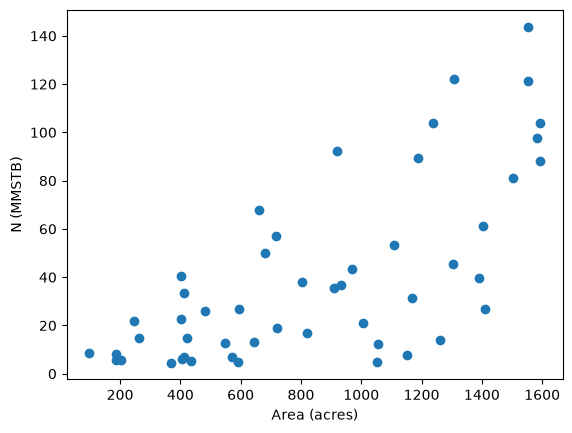

In [4]:
plt.scatter(df["Area (acres)"], df["N (MMSTB)"])
plt.xlabel(df.columns[1]);
plt.ylabel(df.columns[6]);

`plt.scatter(x, y)` crea una gráfica de dispersión, es decir, representa cada observación mediante un punto.

Una **gráfica de dispersión** (*scatter plot*) permite analizar visualmente la relación entre dos variables cuantitativas. Cada punto de la gráfica representa una observación del conjunto de datos.

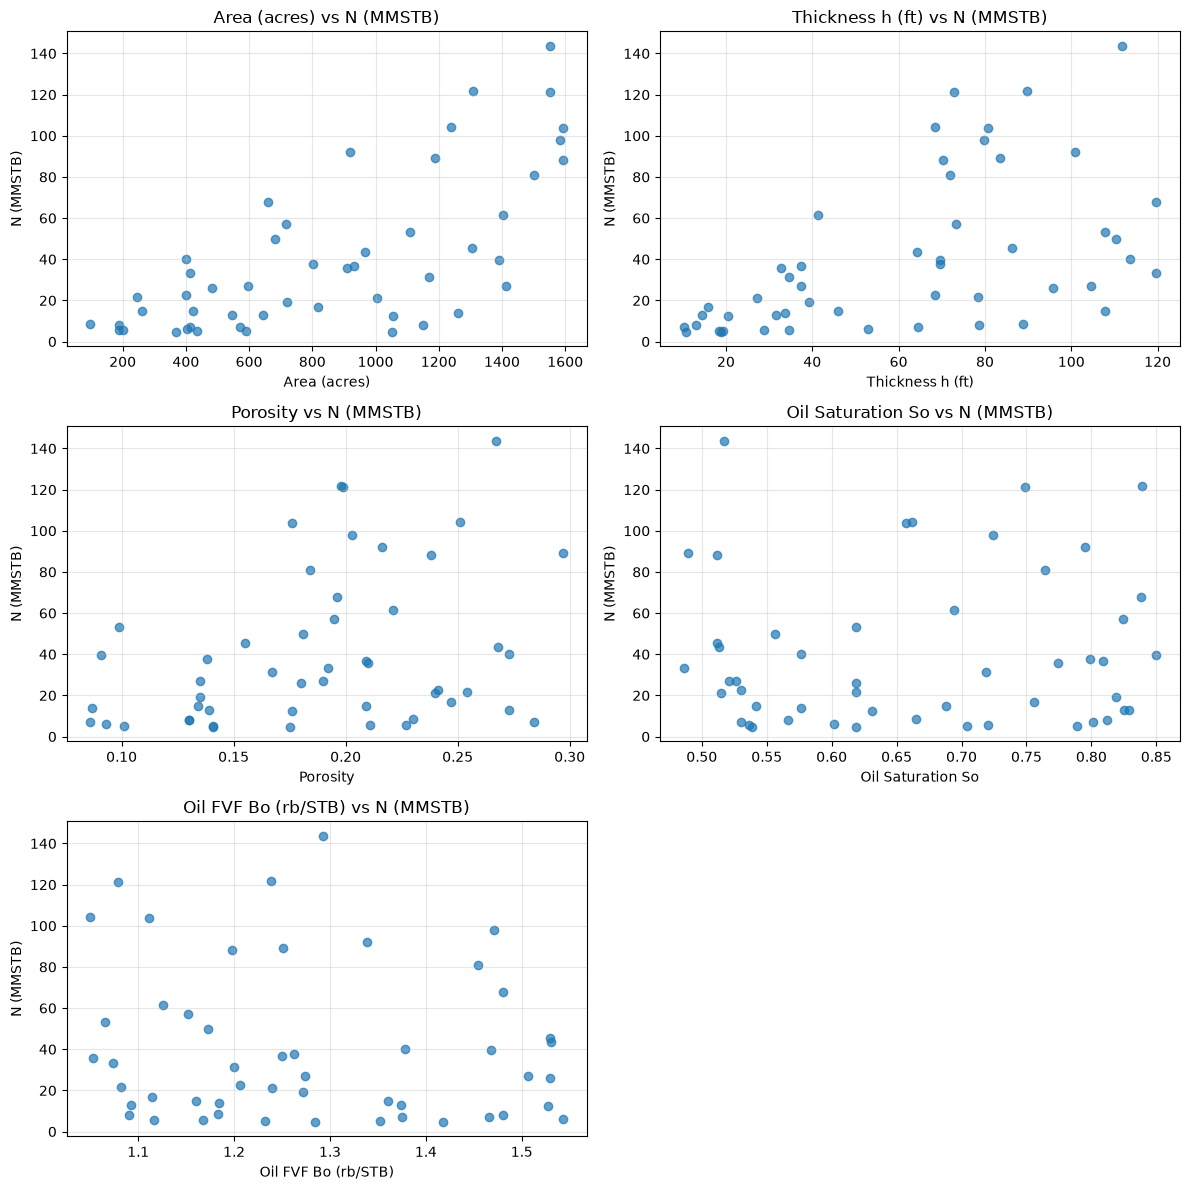

In [5]:
# Séptima columna como variable Y
y = df.iloc[:, 6]

# 3 filas × 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Convertir axes a un arreglo 1D
axes = axes.flatten()

for i in range(5):
    
    x = df.iloc[:, i+1]
    
    axes[i].scatter(x, y, alpha=0.7)
    
    axes[i].set_xlabel(df.columns[i+1])
    axes[i].set_ylabel(df.columns[6])
    axes[i].set_title(
        f"{df.columns[i+1]} vs {df.columns[6]}"
    )
    
    axes[i].grid(alpha=0.3)

# Eliminar el sexto subplot vacío
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Estas gráficas forman parte del **Análisis Exploratorio de Datos (EDA)** y permiten comparar visualmente cada variable predictora con la variable objetivo **N (MMSTB)**.

A partir de la distribución de los puntos se puede identificar si existe una posible:

- **Relación positiva:** al aumentar X, también tiende a aumentar Y.
- **Relación negativa:** al aumentar X, Y tiende a disminuir.
- **Relación débil o nula:** no se observa una tendencia clara.
- **Presencia de valores atípicos:** puntos que presentan un comportamiento diferente al resto de los datos.

Este análisis visual proporciona una primera aproximación para determinar cuáles variables podrían estar más relacionadas con **N (MMSTB)** antes de calcular medidas estadísticas.

# Matriz de Correlación (Correlation Matrix)

Una **matriz de correlación** permite analizar la relación lineal entre diferentes variables numéricas de un conjunto de datos.

El coeficiente de correlación toma valores entre **−1 y 1**:

| Correlación | Interpretación |
|---|---|
| Cercana a **+1** | Relación positiva fuerte |
| Cercana a **0** | Relación lineal débil o nula |
| Cercana a **−1** | Relación negativa fuerte |

Una correlación **positiva** indica que, en general, cuando una variable aumenta, la otra también tiende a aumentar.

Una correlación **negativa** indica que, cuando una variable aumenta, la otra tiende a disminuir.

**NOTA:** La correlación mide asociación lineal entre variables, pero no implica causalidad.

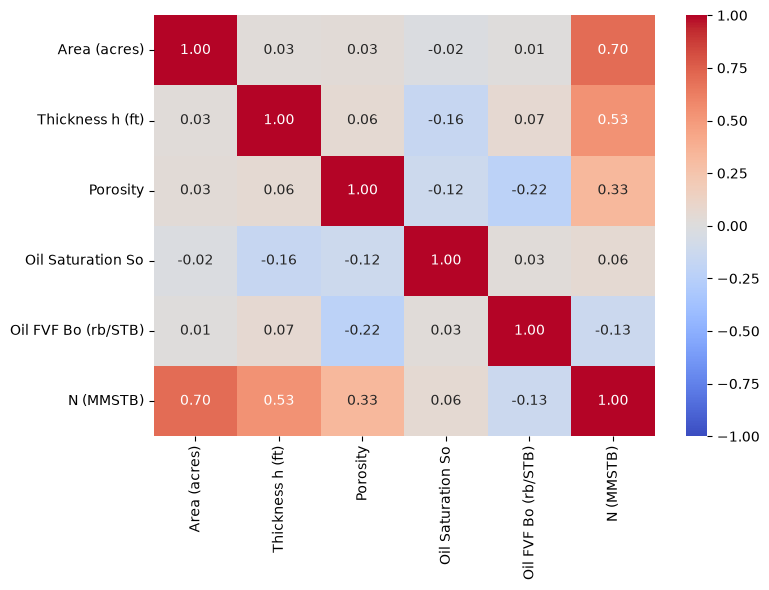

In [6]:
corr = df.iloc[:, 1:7].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1)

plt.tight_layout()
plt.show()

**NOTA:** Al colocar True, Seaborn muestra el valor numérico de la correlación dentro de cada celda.

- `annot=True` → muestra los valores numéricos.
- `annot=False` → oculta los valores numéricos.

**¿Cómo interpretar el mapa de calor?**

El mapa de calor permite identificar rápidamente cuáles variables presentan una mayor relación lineal.

Se debe observar tanto el **signo** como la **magnitud** del coeficiente:

- Valores cercanos a **+1** → relación positiva fuerte.
- Valores cercanos a **−1** → relación negativa fuerte.
- Valores cercanos a **0** → relación lineal débil o inexistente.

Si el objetivo es estudiar qué variables están más relacionadas con **N (MMSTB)**, se debe observar principalmente la **fila o columna correspondiente a N (MMSTB)** y comparar sus coeficientes con las demás variables.

**NOTA**: Cuanto más cercano sea el valor a **+1 o −1**, mayor será la intensidad de la relación lineal con `N (MMSTB)`.

# Gráfica de Dispersión con una Tercera Variable

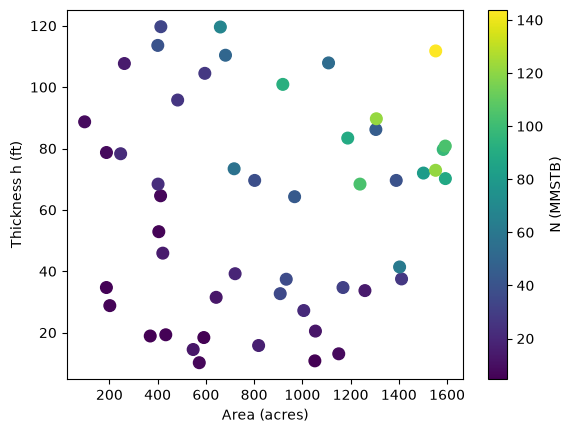

In [7]:
 # Gráfica de dispersión simple
plt.scatter(df["Area (acres)"],df["Thickness h (ft)"])

# Incorporación de una tercera variable
plt.scatter(df["Area (acres)"],df["Thickness h (ft)"],c=df["N (MMSTB)"],cmap="viridis",s=70) 
plt.colorbar(label="N (MMSTB)")
plt.xlabel("Area (acres)")
plt.ylabel("Thickness h (ft)")
plt.show()

Esta gráfica permite analizar simultáneamente **tres variables numéricas**:

**Area → posición horizontal (X)**  
**Thickness h (ft) → posición vertical (Y)**  
**N (MMSTB) → color del punto**

Por lo tanto, además de observar la posible relación entre **Area** y **Thickness**, también podemos identificar cómo cambia **N (MMSTB)** para las diferentes combinaciones de estas dos variables.

Esto permite detectar visualmente **tendencias, agrupamientos, dispersión y observaciones con valores altos o bajos de N**.

# Transformación y combinación de variables

En esta sección se generan tres gráficas de dispersión para comparar cómo se relaciona la variable objetivo **N (MMSTB)** con:

1. **Area**
2. **Area / Porosity**
3. **Area × Porosity**

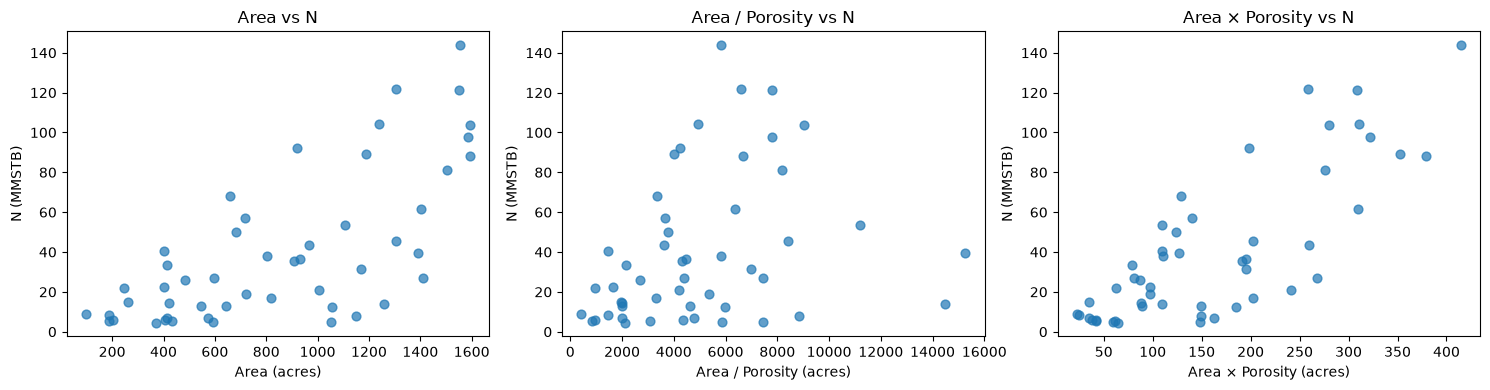

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Area vs N
axes[0].scatter(df["Area (acres)"],df["N (MMSTB)"],alpha=0.7,s=40)
axes[0].set_xlabel("Area (acres)")
axes[0].set_ylabel("N (MMSTB)")
axes[0].set_title("Area vs N")


# 2. Area / Porosity vs N
axes[1].scatter(df["Area (acres)"] / df["Porosity"],df["N (MMSTB)"],alpha=0.7,s=40)
axes[1].set_xlabel("Area / Porosity (acres)")
axes[1].set_ylabel("N (MMSTB)")
axes[1].set_title("Area / Porosity vs N")


# 3. Area × Porosity vs N
axes[2].scatter(df["Area (acres)"] * df["Porosity"],df["N (MMSTB)"],alpha=0.7,s=40)
axes[2].set_xlabel("Area × Porosity (acres)")
axes[2].set_ylabel("N (MMSTB)")
axes[2].set_title("Area × Porosity vs N")


plt.tight_layout()
plt.show()

El objetivo principal es comparar visualmente las tres gráficas y determinar qué variable presenta una relación más clara con **N (MMSTB)**.

Se debe observar principalmente:

- La dirección de la tendencia de los puntos.
- La dispersión de los datos.
- La presencia de posibles valores atípicos.
- Si los puntos presentan una tendencia lineal más definida.


Al comparar las tres gráficas de dispersión se observan diferentes comportamientos:

- **Area vs N:** presenta una tendencia positiva; a medida que aumenta el área, los valores de **N (MMSTB)** tienden a aumentar. Sin embargo, existe una dispersión considerable, indicando que el área por sí sola no explica completamente el comportamiento de N.

- **Area / Porosity vs N:** presenta una mayor dispersión y una tendencia menos definida. Por lo tanto, dividir el área entre la porosidad no parece mejorar visualmente la relación con N.

- **Area × Porosity vs N:** presenta una tendencia positiva más clara. Los valores mayores de **Area × Porosity** tienden a estar asociados con valores mayores de **N (MMSTB)**.

De las tres gráficas, **Area × Porosity** parece presentar visualmente la relación más definida con **N**. Esto sugiere que combinar variables puede proporcionar información adicional que no se observa al analizar únicamente el área.


# Variable combinada (Grouped Feature)


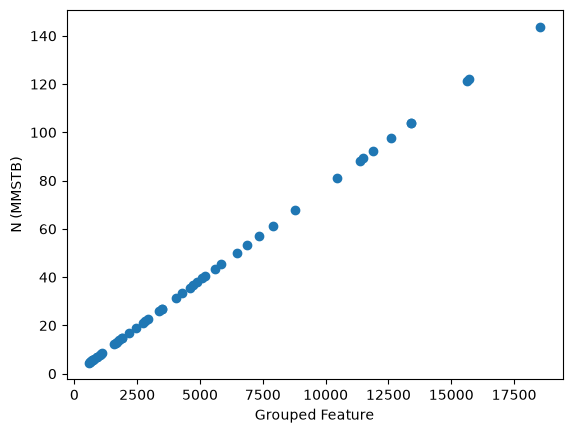

In [9]:
plt.scatter(df["Grouped Feature"], df["N (MMSTB)"])
plt.xlabel(df.columns[7]);
plt.ylabel(df.columns[6]);

La variable **Grouped Feature** se construye mediante la combinación de diferentes propiedades del yacimiento:

$$
\text{Grouped Feature} = \frac{A\,\phi\,h\,S_o}{B_o}
$$

donde:

- $A$ = área del yacimiento (acres).
- $\phi$ = porosidad (fracción).
- $h$ = espesor de la formación (ft).
- $S_o$ = saturación de aceite (fracción).
- $B_o$ = factor volumétrico del aceite (rb/STB).

Esta variable agrupa algunos de los principales parámetros que intervienen en el cálculo volumétrico del aceite original in situ.

La ecuación volumétrica está dada por:

$$
N=\frac{7758\,A\,h\,\phi\,S_o}{B_o}
$$

La gráfica muestra una relación positiva muy fuerte entre **Grouped Feature** y **N (MMSTB)**.

Se observa que:

- Conforme aumenta **Grouped Feature**, también aumenta **N (MMSTB)**.
- Los puntos siguen una tendencia ascendente.
- Existe muy poca dispersión de los puntos alrededor de una tendencia lineal.

Visualmente, esto sugiere que **Grouped Feature** presenta una correlación positiva muy alta con **N (MMSTB)**.

# Pair Plot (Gráfico de pares)

In [10]:
headers=df.columns.tolist()
print(headers)

['Sample', 'Area (acres)', 'Thickness h (ft)', 'Porosity', 'Oil Saturation So', 'Oil FVF Bo (rb/STB)', 'N (MMSTB)', 'Grouped Feature']


`headers = df.columns.tolist()`

Esta instrucción permite obtener los nombres de todas las columnas del DataFrame y almacenarlos en una lista.

Se puede dividir en dos partes:

- `df.columns` → obtiene los **nombres de las columnas** del DataFrame.
- `.tolist()` → convierte los nombres de las columnas en una **lista de Python**.

**NOTA**: Se utilizara en el siguiente codigo 

Un **Pair Plot** permite visualizar simultáneamente las relaciones existentes entre múltiples variables de un conjunto de datos.

Esta herramienta es útil durante el **Análisis Exploratorio de Datos (EDA)**, ya que permite identificar tendencias, relaciones, distribuciones y posibles valores atípicos.

Permite identificar visualmente:

- Relaciones positivas.
- Relaciones negativas.
- Relaciones débiles o nulas.
- Tendencias lineales o no lineales.
- Agrupamientos.
- Posibles valores atípicos.

**Creación del Pair Plot**

`sns.pairplot(df[variables], diag_kind="hist")`

La función `sns.pairplot()` genera automáticamente una **matriz de gráficas** donde las variables se comparan entre sí.

`df[variables]`

selecciona del DataFrame las columnas cuyos nombres se encuentran almacenados en `variables`.

Cada **fila y columna** de la matriz corresponde a una variable diferente.

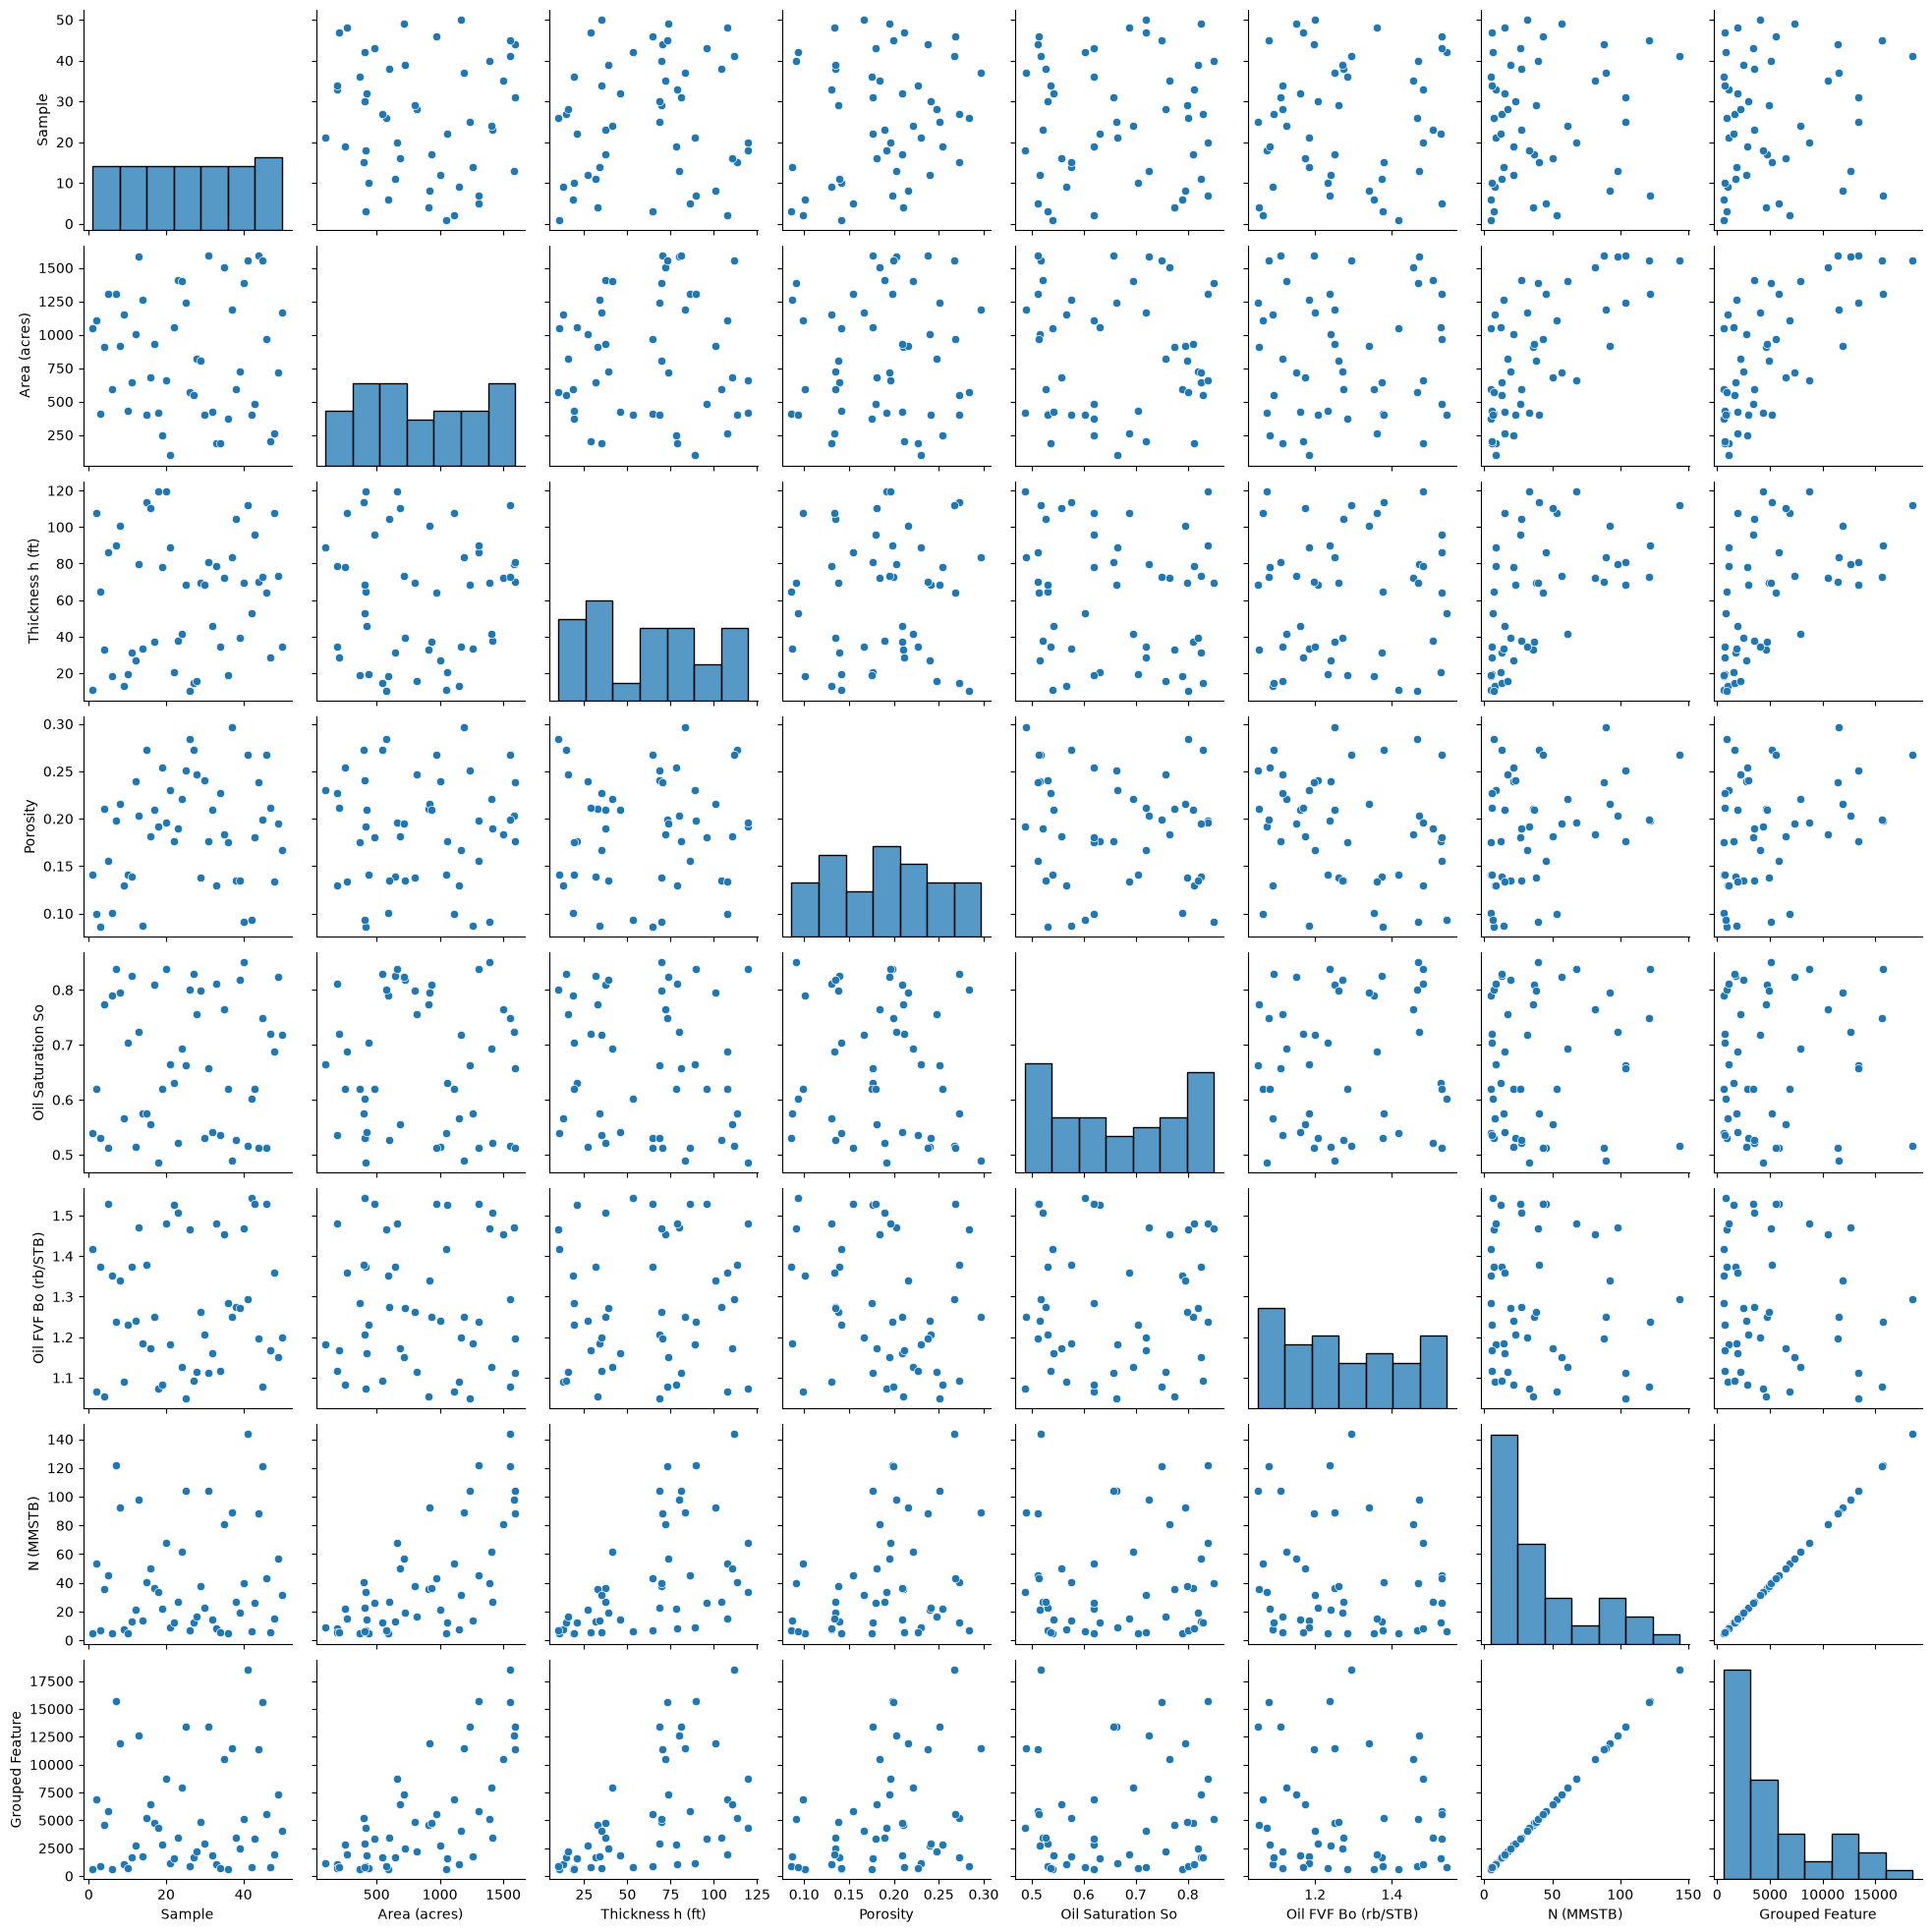

In [11]:
variables = headers


sns.pairplot(
    df[variables],
    diag_kind="hist"
)

plt.show()

Las gráficas de dispersión permiten identificar cuáles variables parecen presentar una relación con **N (MMSTB)**, mientras que los histogramas de la diagonal permiten analizar la distribución individual de cada variable.

Cuando los puntos de una gráfica presentan una tendencia claramente ascendente, existe evidencia visual de una **relación positiva**. Si presentan una tendencia descendente, existe una **relación negativa**. Si los puntos se encuentran muy dispersos y sin una dirección definida, la relación entre las variables puede ser débil.

Este análisis constituye una primera aproximación visual. La intensidad de las relaciones puede evaluarse posteriormente mediante medidas estadísticas como el **coeficiente de correlación**.

**¿Por qué la diagonal no tiene Scatter Plot?**

Porque en la diagonal una variable estaría siendo comparada consigo misma.